# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [1]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [2]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [3]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS, feature_importance_by_tier
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS, feature_importance_by_tier
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [4]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)
df['has_feature_mods'] = df[[c for c in df.columns if 'feature_' in c]].sum(axis=1) > 0

In [5]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [6]:
phase3_features = get_phase3_features()

In [7]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [8]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [9]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.3664
      Test MAE: 5.13 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.2428
      Test MAE: 15.01 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  -0.7259
      Test MAE: 31.00 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.1931
      Test MAE: 22.48 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.3874
      Test MAE: 86.87 HP

All 5 models trained successfully!


In [10]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                    feature   coefficient
           has_spellcasting -2.001182e+00
          spellcaster_level  1.706091e+00
         inflicts_petrified -1.482292e+00
           inflicts_blinded -1.356027e+00
         inflicts_paralyzed -1.094933e+00
     size_ordinal_deviation  5.147859e-01
        vulnerability_count  4.277272e-01
        inflicts_frightened -1.756029e-01
    has_regeneration_scaled -2.109424e-15
legendary_actions_per_round  4.440892e-16

CR2 Top Features by Coefficient:
                    feature   coefficient
           inflicts_charmed -6.362461e+00
           has_spellcasting -5.092485e+00
          spellcaster_level  3.868149e+00
         inflicts_petrified -3.126591e+00
        vulnerability_count  2.770066e+00
         inflicts_paralyzed -2.014298e+00
          inflicts_poisoned -9.832568e-01
     size_ordinal_deviation  8.776799e-01
     inflicts_incapacitated -2.473942e-01
legendary_actions_per_round -3.552714e-15

CR3 Top

## Investigate Specific Creatures

In [11]:
# df[df['Name'].str.contains('Dragon')].head()

In [12]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# Oni, Unicorn way too penalized for different reasons.
investigate_creature('Oni', df, contributions_df)

  ONI (CR 7.0)

Actual HP:             110
Predicted HP:          135
Error:                  25  (  23.1%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 7.0):                               156
  Feature HP (DMG adjustments):                       -30
  HP after Phase 1:                                     126

PHASE 2: COMBAT STATS

  Deviation Breakdown:
    Stat         Estimated   Feature    Total  Baseline  Deviation
    ------------------------------------------------------------
    AC                  16        +4       20        15         +5
    Attack               7        +0        7         7         +0
    DPR                 30        +0       30        47        -17
    Save DC             13        --       13        15         -2

  Costed DMG Features:
    feature_ac (+4):  saving_throws (4 saves) +2, flying (CR 7) +2
    feature_attack (+0):  (none)
    feature_dpr (+0):  (none)
    feature

In [13]:
df[df['Name']=='Cloaker'][[c for c in df.columns if 'dpr' in c]]

,dpr_baseline,estimated_dpr,feature_dpr,legendary_dpr,total_dpr,dpr_deviation
262,53.0,17.5,0.0,0,17.5,-35.5


In [14]:
# _df = analysis_dfs['cr3']
# _df.sort_values('predicted_hp')

In [15]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [16]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
        Name    CR  Actual_HP  Predicted_HP         Error
     Cultist 0.125          9      9.000000 -3.094214e-07
  Cockatrice 0.500         27     26.999933  6.729364e-05
      Stirge 0.125          2      2.029192 -2.919179e-02
    Commoner 0.000          4      4.125000 -1.250000e-01
         Owl 0.000          1      0.654192  3.458082e-01
Magma Mephit 0.500         22     21.518963  4.810368e-01
 Dust Mephit 0.500         17     17.515523 -5.155231e-01
   Giant Rat 0.125          7      6.327096  6.729041e-01
  Blood Hawk 0.125          7      6.327096  6.729041e-01
    Warhorse 0.500         19     18.297904  7.020959e-01

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
         Rust Monster 0.50         27     37.375000 -10.375000
Giant Poisonous Snake 0.25         11      0.000000  11.000000
           Giant Wasp 0.50         13     24.574530 -11.574530
            Hobgoblin 0.50         11     22.62

In [17]:
_df_check = analysis_dfs['cr2']
[c for c in _df_check.columns if 'immun' in c]


['hp_after_resist_immun_penalty',
 'immunity_count',
 'feature_spell_immunity',
 'feature_turn_immunity']

In [18]:
# _df_check = analysis_dfs['cr2']
# _df_check[_df_check['actual_hp'] == 45]



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


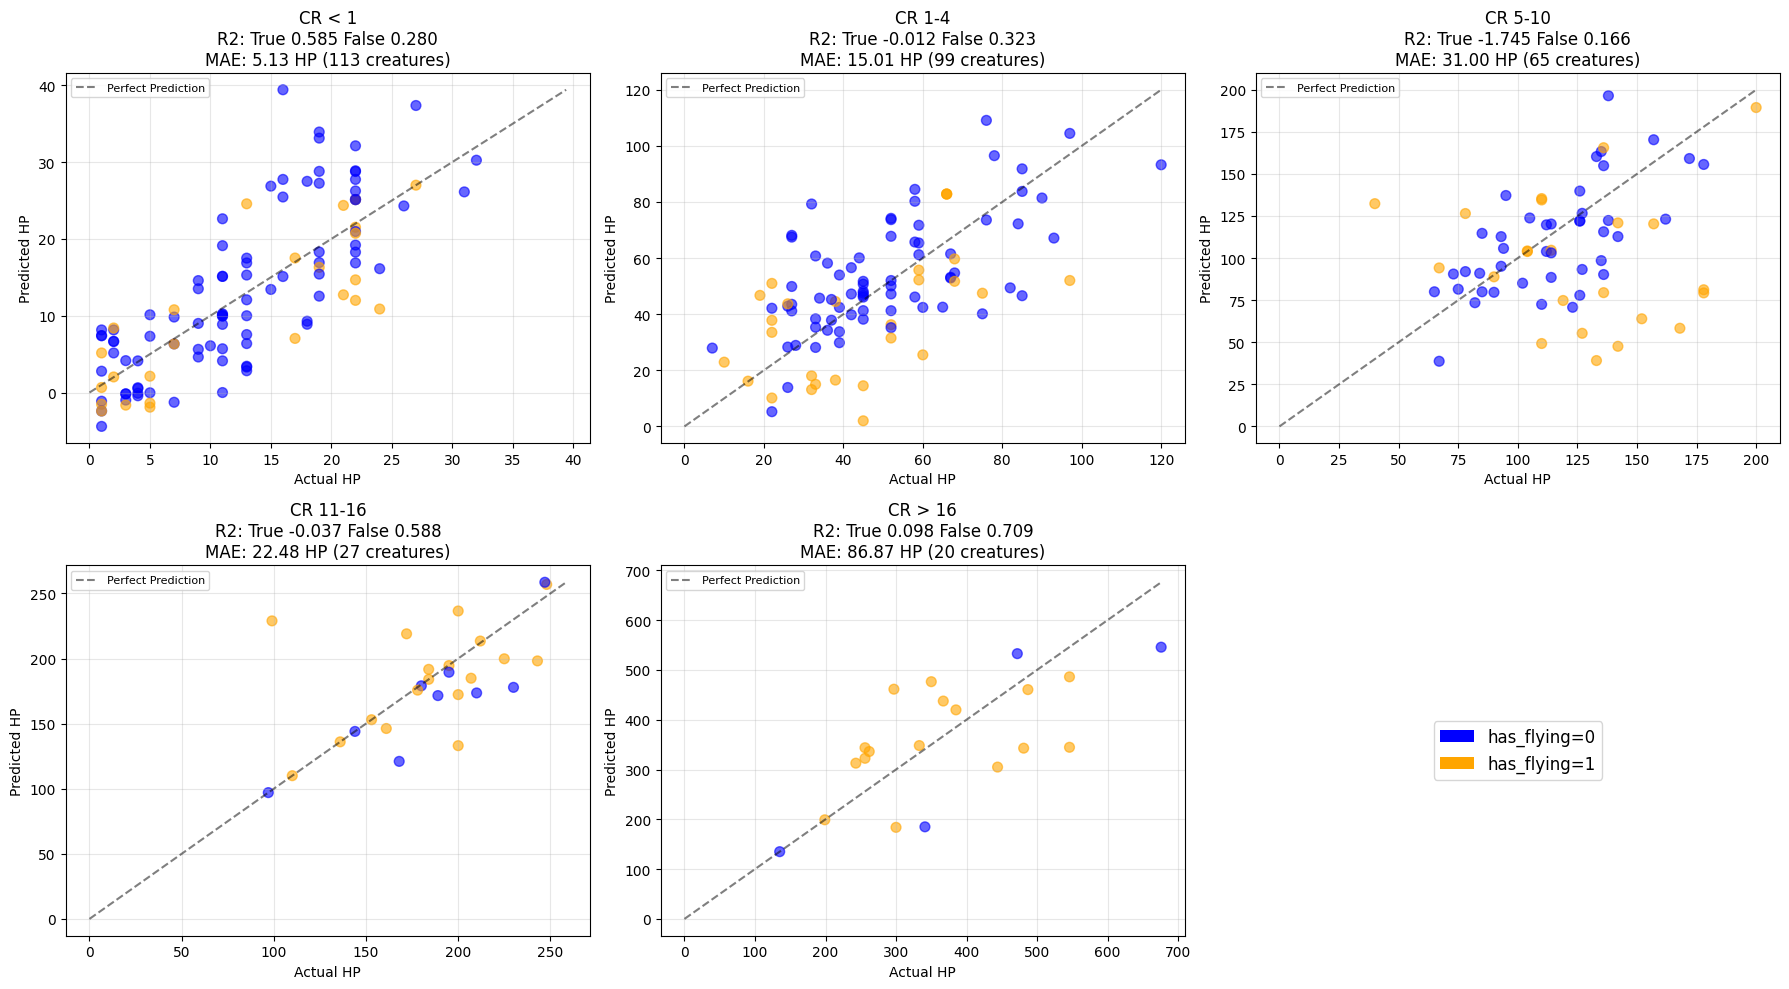

In [19]:

plot_performance_scatter(analysis_dfs, highlight_feature='has_flying')

In [20]:
for k, v in df[df['Name']=='Hill Giant'][[c for c in df.columns if 'feature' in c]].iloc[0].items():
    print(f"{k}: {v}")

feature_dpr: 0.0
feature_ac: 0
feature_attack: 0
feature_hp: 0.0
feature_aggressive: 0
feature_ambusher: 0
feature_amorphous: 0
feature_amphibious: 0
feature_angelic_weapons: 0
feature_antimagic_susceptibility: 0
feature_avoidance: 0
feature_blind_senses: 0
feature_blood_frenzy: 0
feature_breath_weapon: 0
feature_brute: 0
feature_charge: 0
feature_charm: 0
feature_constrict: 0
feature_damage_absorption: 0
feature_damage_transfer: 0
feature_death_burst: 0
feature_devils_sight: 0
feature_dive_attack: 0
feature_echolocation: 0
feature_elemental_body: 0
feature_enlarge: 0
feature_etherealness: 0
feature_false_appearance: 0
feature_fey_ancestry: 0
feature_fiendish_blessing: 0
feature_flyby: 0
feature_frightful_presence: 0
feature_grapple: 0
feature_grappler: 0
feature_hold_breath: 0
feature_horrifying_visage: 0
feature_illumination: 0
feature_immutable_form: 0
feature_incorporeal_movement: 0
feature_innate_spellcasting: 0
feature_invisibility: 0
feature_keen_senses: 0
feature_labyrinthine_r

In [21]:
_df = analysis_dfs['cr3']
_df.sort_values('predicted_hp')

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile,hp_baseline,ac_baseline,attack_baseline,...,has_attackers_advantage,inflicts_prone,has_grapple,has_feature_mods,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
23,Unicorn,5.0,67,38.696490,-28.303510,-42.244045,80.000000,114.0,15.0,7.0,...,0,1,0,True,67,38.696490,5.0,28.303510,28.303510,42.244045
27,Young White Dragon,6.0,133,39.112500,-93.887500,-70.592105,98.461538,134.4,15.0,7.0,...,0,0,0,True,133,39.112500,6.0,93.887500,93.887500,70.592105
44,Young Bronze Dragon,8.0,142,47.587500,-94.412500,-66.487676,96.923077,163.2,15.0,7.0,...,0,0,0,True,142,47.587500,8.0,94.412500,94.412500,66.487676
28,Young Brass Dragon,6.0,110,49.237500,-60.762500,-55.238636,87.692308,134.4,15.0,7.0,...,0,0,0,True,110,49.237500,6.0,60.762500,60.762500,55.238636
36,Young Black Dragon,7.0,127,55.312500,-71.687500,-56.446850,90.769231,156.0,15.0,7.0,...,0,0,0,True,127,55.312500,7.0,71.687500,71.687500,56.446850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,Aboleth,10.0,135,163.303130,28.303130,20.965281,50.769231,186.0,17.0,9.0,...,0,0,0,True,135,163.303130,10.0,-28.303130,28.303130,-20.965281
60,Deva,10.0,136,165.579745,29.579745,21.749813,53.846154,186.0,17.0,9.0,...,0,0,0,True,136,165.579745,10.0,-29.579745,29.579745,-21.749813
39,Giant Ape,7.0,157,170.313615,13.313615,8.480010,24.615385,156.0,15.0,7.0,...,0,0,0,False,157,170.313615,7.0,-13.313615,13.313615,-8.480010
57,Cloud Giant,9.0,200,189.436521,-10.563479,-5.281739,12.307692,174.0,16.0,8.0,...,0,0,0,True,200,189.436521,9.0,10.563479,10.563479,5.281739



📊 VISUALIZATION: Error Distribution (5 CR Buckets)


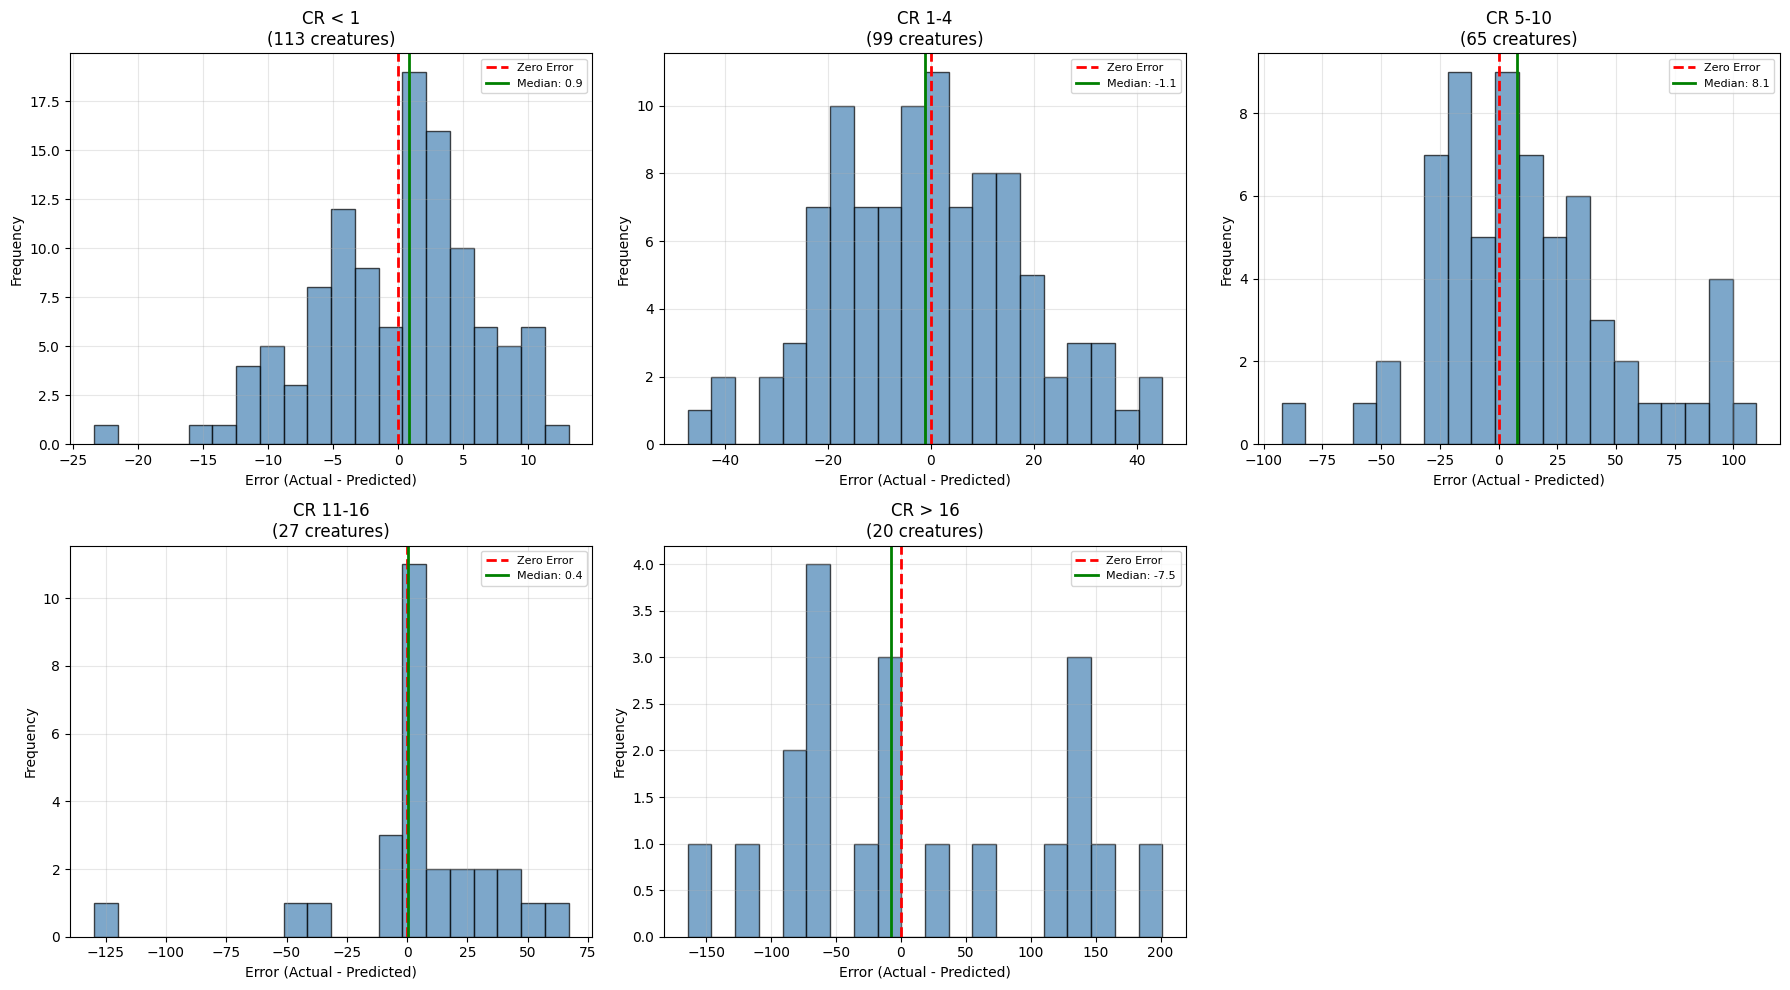

In [22]:
plot_error_hist(analysis_dfs)

# Feature Importance

In [23]:
importance_df = feature_importance_by_tier(contributions_df)

FEATURE IMPORTANCE BY CR TIER

  PHASE 1: AGGREGATE DMG FEATURE COSTS (mean across tier)
  Feature                                 CR < 1     CR 1-4    CR 5-10   CR 11-16    CR > 16
  ------------------------------------------------------------------------------------------
  feature_hp  (HP impact)                   -0.0       -1.2       -3.1      -32.2      -84.0
  feature_dpr  (stat adj.)                   0.4        4.1       10.3       24.9       55.4
  feature_ac  (stat adj.)                    0.2        0.7        1.7        2.2        2.5
  feature_attack  (stat adj.)                0.2        0.1        0.1        0.0        0.0

  PHASE 2: SPECIFIED PENALTIES (mean across tier)
  Feature                                 CR < 1     CR 1-4    CR 5-10   CR 11-16    CR > 16
  ------------------------------------------------------------------------------------------
  ac_deviation                              -1.6       -2.8       -6.8       -9.2      -23.4
    (per unit penalty) 

In [24]:
importance_df

,phase,feature,CR < 1,CR 1-4,CR 5-10,CR 11-16,CR > 16
0,Phase 1,feature_hp,-0.000000,-1.197576,-3.101538,-32.222222,-84.000000
1,Phase 1,feature_dpr,0.438053,4.055556,10.315385,24.851852,55.391667
2,Phase 1,feature_ac,0.212389,0.737374,1.692308,2.185185,2.500000
3,Phase 1,feature_attack,0.212389,0.141414,0.061538,0.000000,0.000000
4,Phase 2,ac_deviation,-1.606195,-2.828283,-6.784615,-9.166667,-23.400000
5,Phase 2,save_dc_deviation,0.061947,0.808081,1.846154,-2.777778,-31.050000
6,Phase 2,attack_deviation,-1.053097,-0.121212,-1.538462,-3.518519,-20.800000
7,Phase 2,dpr_deviation,-1.161504,0.222222,1.283654,10.111111,-0.883333
8,Phase 2,inflicts_prone,-0.079646,-0.170455,-0.207692,-0.833333,-1.950000
9,Phase 2,has_advantage_condition,-0.066372,-0.113636,-0.230769,-0.416667,-0.243750
